<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_03_Francisco_Javier_Moya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°3 de TPS: Regresión Polinómica

Este TP trata de reconocer comandos de voz de forma automática. Para eso, se toman audios, se los transforma en una representación más útil usando la STFT y bandas de energía, y luego esas características se usan para entrenar una regresión logística que clasifique qué palabra fue dicha.


Se importan las librerías y las bibliotecas que se usarán.

In [ ]:
import os
import requests
import tarfile
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import glob
import random
import numpy as np


## Ítem A: Preprocesamiento

En esta primera parte del trabajo práctico se prepara la información que después se usará para clasificar comandos de voz. Para eso, primero se descargan y exploran algunos audios de la base de datos, observando su forma de onda y escuchándolos para familiarizarse con las señales. Luego, cada audio se analiza en el dominio tiempo-frecuencia mediante la transformada de Fourier de corto tiempo (STFT), usando ventanas de 512 puntos con 50\% de solapamiento y ventana de Hann. A partir de ese espectro, se resume la información dividiéndolo en 20 bandas de frecuencia y calculando la energía en cada una. Finalmente, esas energías se expresan en decibeles, obteniendo así una representación más compacta y adecuada para las etapas posteriores de clasificación.

### Punto 1

Se descarga de manera autocontenida la base de datos.

In [2]:
# --- PUNTO A.1: Descargar y descomprimir la base de datos ---
url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
target_path = "speech_commands_v0.02.tar.gz"
extract_folder = "speech_data"

if not os.path.exists(extract_folder):
    print("Descargando base de datos... ")
    response = requests.get(url, stream=True)
    with open(target_path, "wb") as f:
        f.write(response.raw.read())

    print("Extrayendo archivos...")
    with tarfile.open(target_path, "r:gz") as tar:
        tar.extractall(path=extract_folder)
    print("¡Proceso completado!")
else:
    print("La base de datos ya existe localmente.")

Descargando base de datos... 
Extrayendo archivos...


/tmp/ipykernel_15747/2609470521.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_folder)


¡Proceso completado!


### Puntos 2 y 3

Se seleccionan tres audios al azar, se grafican en el dominio del tiempo y luego se reproducen.

Audio 1: speech_data/happy/27c30960_nohash_1.wav [Punto A.2]


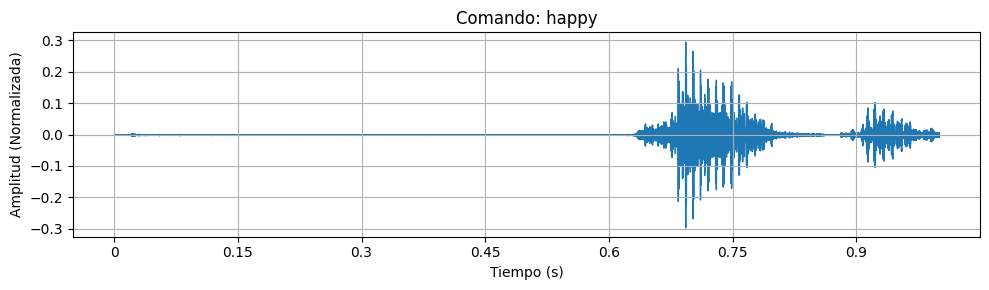

Audio 2: speech_data/three/7f74626f_nohash_1.wav [Punto A.2]


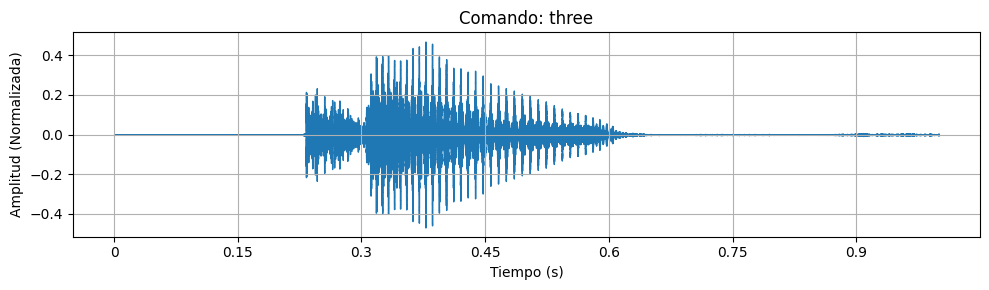

Audio 3: speech_data/six/f822b9bf_nohash_4.wav [Punto A.2]


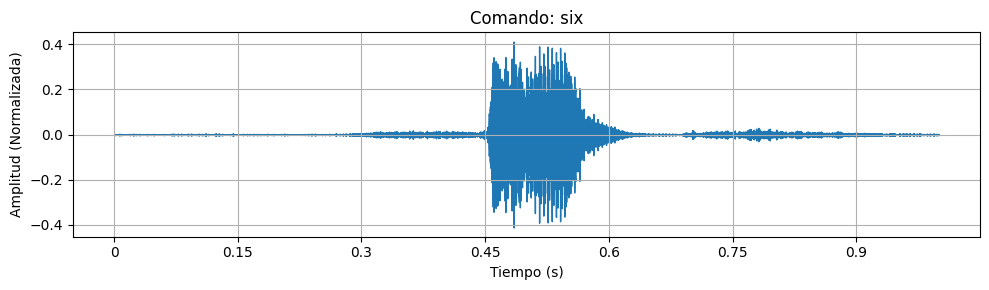

In [3]:
# --- PUNTO A.2: Cargar al menos tres audios utilizando librosa ---
audio_files = glob.glob(os.path.join(extract_folder, "*/*.wav"))
samples_to_load = random.sample(audio_files, 3)

for i, path in enumerate(samples_to_load):
    y, sr = librosa.load(path, sr=None)
    print(f"Audio {i+1}: {path} [Punto A.2]")

    # --- PUNTO A.3: Reproducir y Graficar (ahora con labels) ---
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)

    plt.title(f"Comando: {os.path.basename(os.path.dirname(path))}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (Normalizada)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    ipd.display(ipd.Audio(y, rate=sr)) # [Punto A.3]

En los gráficos de las formas de onda se observa que la amplitud toma valores positivos y negativos. Esto se debe a que el micrófono convierte variaciones de presión del aire en una señal eléctrica y la señal oscila alrededor de cero. Cuando la curva va positiva, la tensión instantánea está para un lado de la referencia, cuando va negativa, está para el otro lado. En términos prácticos, lo importante es la magnitud de la amplitud y su evolución temporal, ya que eso refleja la energía y la estructura de la palabra pronunciada.

Además, al cargar los audios se utilizó `librosa.load(path, sr=None)`. Esto es importante porque los archivos originales de la base están muestreados a 16 kHz, y si no se especifica `sr=None`, `librosa` los remuestrea automáticamente a 22.05 kHz. Aunque eso no necesariamente rompe el análisis, sí modifica innecesariamente los datos originales, por lo que conviene mantener la frecuencia de muestreo original del dataset.

### Punto 4

En esta parte del TP el objetivo es pasar del audio crudo a una representación que muestre cómo se reparte la energía en frecuencia a medida que pasa el tiempo. Para eso se usa la STFT: en vez de calcular una sola transformada de Fourier para todo el audio, se divide la señal en tramos cortos y se calcula una FFT en cada uno. Esto es necesario porque una palabra no es estacionaria, las frecuencias presentes al principio, en el medio y al final no son las mismas. Por eso interesa mirar el contenido espectral localmente en el tiempo y no solo en promedio.

En señales de voz suelen usarse ventanas de entre 20 y 40 ms porque, en intervalos tan cortos, la señal puede considerarse aproximadamente estacionaria o cuasiestacionaria: su contenido espectral no cambia demasiado dentro de esa ventana. Eso permite que la FFT tenga sentido como una descripción local del sonido. Si la ventana fuera mucho más larga, mezclaría partes distintas de la palabra y se perdería información temporal importante. Mientras que si fuera demasiado corta, la resolución en frecuencia sería muy pobre. En este caso, usar `n_fft = 512` con \($f_s = 16\text{ kHz}$\) equivale a una ventana de 32 ms, que cae dentro de ese rango típico. La resolución en frecuencia resultante es de \($16000/512 = 31.25$\) Hz, que es suficiente para este TP porque no se busca medir frecuencias exactas con gran precisión, sino capturar cómo se distribuye la energía espectral de la voz y cómo esa distribución cambia en el tiempo. En otras palabras, para distinguir palabras no alcanza con mirar solo el tiempo ni solo la frecuencia: interesa una representación tiempo-frecuencia que conserve ambas cosas de manera equilibrada.

Por otro lado, las ventanas se toman con 50\% de solapamiento, es decir, cada nueva ventana empieza a mitad de la anterior. Esto se hace para no “saltearse” información entre bloques consecutivos y para que la representación cambie de forma más suave en el tiempo. Si no hubiera solapamiento, podrían perderse transiciones importantes entre sonidos.

Antes de hacer cada FFT se aplica una ventana de Hann. La idea es suavizar los bordes de cada tramo, porque cortar la señal de golpe genera discontinuidades artificiales que ensucian el espectro. La ventana de Hann reduce ese efecto y hace que la energía quede mejor ubicada en las frecuencias donde realmente está. Como la señal de audio es real, el espectro tiene una parte simétrica, así que solo hace falta trabajar con una mitad.


In [4]:
# --- PUNTO A.4: Calcular la transformada de Fourier de corto tiempo (STFT) ---
def calcular_stft_tp(y):
    # Configuración: FFT 512, Solapamiento 50% (hop 256), Ventana Hann 512
    # Librosa descarta la parte simétrica automáticamente para señales reales.
    stft = librosa.stft(y, n_fft=512, hop_length=256, win_length=512, window='hann', center=False)
    return np.abs(stft)**2 # Retornamos magnitud al cuadrado (energía)


Se utiliza `center=False` en la STFT para evitar el padding automático que `librosa` agrega por defecto en los extremos de la señal. Cuando `center=True`, cada ventana queda centrada respecto del instante temporal representado, pero eso implica extender artificialmente la señal con ceros al principio y al final, modificando la cantidad de ventanas obtenidas. En este trabajo práctico se usa `center=False` porque así la STFT se calcula únicamente sobre las muestras reales del audio, y la cantidad de ventanas temporales queda determinada de forma directa por la longitud de la señal, el tamaño de la ventana y el salto entre ventanas.

### Punto 5

Luego, en lugar de utilizar todos los bins de frecuencia de la STFT, el espectro se resume en 20 bandas de energía.

La STFT proporciona una representación tiempo-frecuencia detallada, con una gran cantidad de bins espectrales en cada ventana temporal. Si bien esa descripción contiene información útil, también introduce un nivel de detalle que no resulta necesario para esta tarea de clasificación. Por este motivo, se agrupan bins vecinos en 20 bandas y se calcula, para cada una, la energía total asociada.

Como la cantidad total de bins disponibles no es múltiplo exacto de 20, la partición no puede hacerse con bandas idénticas. Para resolver esto, los bins se distribuyen de la forma más equitativa posible, de modo que todas las bandas tengan tamaños muy similares y la diferencia entre ellas sea, como máximo, de un bin. Así se evita que una única banda concentre una porción excesiva del espectro.

De esta manera se reduce la cantidad de datos, pero se conserva la información más importante para el problema: cómo se distribuye la energía en frecuencia y cómo esa distribución evoluciona en el tiempo. En otras palabras, se disminuye la resolución espectral, manteniendo una representación compacta y adecuada para distinguir entre los comandos de voz.

In [5]:
# --- PUNTO A.5: Descomponer el espectro en 20 bandas de energía ---
def calcular_bandas_20(espectro, imprimir_bandas=False):
    n_bins, n_frames = espectro.shape
    bandas_idx = np.array_split(np.arange(n_bins), 20)

    energias = np.zeros((20, n_frames))

    for i, idx in enumerate(bandas_idx):
        energias[i, :] = np.sum(espectro[idx, :], axis=0)

    return energias

Se verifica a continuación que la partición del espectro en 20 bandas distribuya los bins de frecuencia de manera lo más uniforme posible. Este chequeo permite corroborar que la separación realizada sea consistente y que no queden bins sin asignar.

Nota: como la cantidad total de bins no es múltiplo de 20, algunas bandas pueden diferir en un bin respecto de otras.

In [6]:
espectro = calcular_stft_tp(y)
n_bins, _ = espectro.shape
bandas_idx = np.array_split(np.arange(n_bins), 20)

print("Distribución de bins por banda:")
for i, idx in enumerate(bandas_idx):
    print(f"Banda {i:2d}: bins {idx[0]:3d} a {idx[-1]:3d} -> {len(idx):2d} bins")

print("Total de bins:", sum(len(idx) for idx in bandas_idx))

Distribución de bins por banda:
Banda  0: bins   0 a  12 -> 13 bins
Banda  1: bins  13 a  25 -> 13 bins
Banda  2: bins  26 a  38 -> 13 bins
Banda  3: bins  39 a  51 -> 13 bins
Banda  4: bins  52 a  64 -> 13 bins
Banda  5: bins  65 a  77 -> 13 bins
Banda  6: bins  78 a  90 -> 13 bins
Banda  7: bins  91 a 103 -> 13 bins
Banda  8: bins 104 a 116 -> 13 bins
Banda  9: bins 117 a 129 -> 13 bins
Banda 10: bins 130 a 142 -> 13 bins
Banda 11: bins 143 a 155 -> 13 bins
Banda 12: bins 156 a 168 -> 13 bins
Banda 13: bins 169 a 181 -> 13 bins
Banda 14: bins 182 a 194 -> 13 bins
Banda 15: bins 195 a 207 -> 13 bins
Banda 16: bins 208 a 220 -> 13 bins
Banda 17: bins 221 a 232 -> 12 bins
Banda 18: bins 233 a 244 -> 12 bins
Banda 19: bins 245 a 256 -> 12 bins
Total de bins: 257


### Punto 6


Esas energías se convierten a dB para trabajar en una escala logarítmica más cómoda. Esto permite comprimir el rango dinámico de la señal, evitando que las bandas con mucha energía tapen numéricamente a las más débiles. Así, la comparación entre distintas partes del espectro resulta más clara y la representación final queda mejor adaptada para las etapas posteriores de clasificación.

In [7]:
# --- PUNTO A.6: Convertir la energía en dB ---
def energia_a_db(E):
    E_max = np.max(E)
    eps = 1e-10 # Epsilon para evitar log(0)
    # Fórmula: 10 * log10(E / E_max)
    return 10 * np.log10((E + eps) / (E_max + eps))

### Resultado del preprocesamiento

En esta celda se aplica todo el flujo del inciso (A) a un único audio de ejemplo. Es decir, se toma una señal, se calcula su STFT, luego se resume el espectro en 20 bandas de energía y finalmente esas energías se convierten a dB. El resultado es una matriz donde cada columna representa una ventana temporal y cada fila una banda de frecuencia (son 20 filas en total).

Procesamiento finalizado. Matriz resultante: (20, 61)


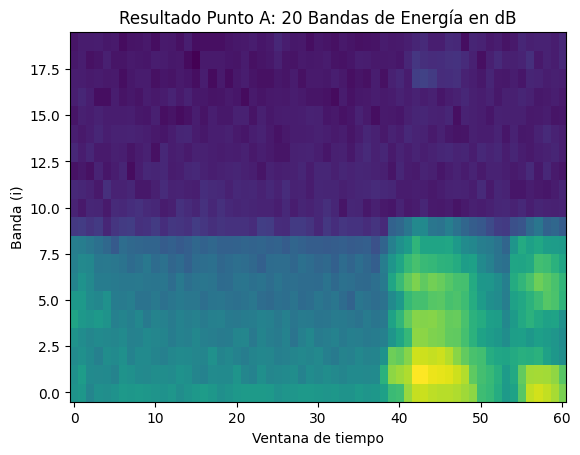

In [8]:
# Demostración del flujo completo del Inciso (a)
audio_test, sr_test = librosa.load(samples_to_load[0], sr=None)

# Ejecución secuencial de los puntos 4, 5 y 6
espectro_pot = calcular_stft_tp(audio_test)      # Punto 4
bandas_raw = calcular_bandas_20(espectro_pot)   # Punto 5
bandas_db = energia_a_db(bandas_raw)            # Punto 6

print(f"Procesamiento finalizado. Matriz resultante: {bandas_db.shape}")
plt.imshow(bandas_db, aspect='auto', origin='lower')
plt.title("Resultado Punto A: 20 Bandas de Energía en dB")
plt.ylabel("Banda (i)")
plt.xlabel("Ventana de tiempo")
plt.show()



La representación obtenida tiene menos resolución que un espectrograma clásico, ya que en lugar de conservar todos los bins de frecuencia se agrupa la información en solo 20 bandas. Esto hace que la visualización se vea más “gruesa” o resumida, pero justamente ese es el objetivo: reducir la cantidad de datos y conservar una descripción compacta de cómo se distribuye la energía de la palabra en frecuencia y en el tiempo. Aunque visualmente tenga menos detalle, esta representación resulta más adecuada para usar luego como entrada del clasificador.

## Ítem B: Clasificación binaria de comandos de voz

En este inciso del trabajo práctico se construye un clasificador capaz de distinguir entre dos comandos: `yes` y `no`. Para eso, primero se arma una base de datos con esos audios y se unifica su longitud, de modo que todos generen la misma cantidad de ventanas temporales al aplicar el preprocesamiento. Luego, cada audio se transforma en una matriz de características de tamaño $$50 \times 20$$, que resume cómo se distribuye su energía en frecuencia a lo largo del tiempo. Finalmente, esas características se usan para entrenar una regresión logística binaria implementada desde cero, y se evalúa su desempeño sobre datos de entrenamiento y de prueba.

### Puntos 1 y 2

En esta etapa se empieza a construir el problema de clasificación. En lugar de trabajar con todos los comandos de la base, se seleccionan únicamente los audios correspondientes a las palabras `yes` y `no`. Cada audio se asocia a una etiqueta numérica (`yes = 0`, `no = 1`), de modo que el objetivo posterior será entrenar un modelo que, dado un audio, pueda decidir automáticamente a cuál de estas dos clases pertenece.

Como los audios originales no tienen exactamente la misma duración, es necesario unificarlos para que todos generen la misma cantidad de datos al aplicar el preprocesamiento del punto A. Para eso se fija una longitud objetivo en muestras y se ajusta cada audio de la siguiente manera:
- Si es más largo, se recorta al final.
- Si es más corto, se completa con ceros (*zero-padding*) al final.

Para que todos los audios generen exactamente 50 ventanas temporales, la cantidad de ventanas viene dada por:

$$
N_{\text{frames}} = 1 + \left\lfloor \frac{L - 512}{256} \right\rfloor
$$

Donde $$L$$ es la longitud del audio en muestras. Imponiendo $$N_{\text{frames}}=50$$, se obtiene:

$$
L = 512 + 49\cdot 256 = 13056
$$

Por eso se fija `target_samples = 13056`: así, luego del recorte o zero-padding, todos los audios producen exactamente 50 ventanas al aplicar la STFT.
En resumen, en este paso se arma la base de datos binaria (`yes` vs `no`) y se asegura que todos los audios tengan el mismo formato de entrada para las etapas siguientes.

In [9]:
# --- PUNTO B.1 y B.2: Carga y unificación de audios ---

target_samples = 13056
clases = ['yes', 'no']
X_raw = []
y_labels = []

print("Iniciando carga de audios y unificación de largos...")

for label_idx, clase in enumerate(clases):
    clase_path = os.path.join("speech_data", clase)
    archivos = [f for f in os.listdir(clase_path) if f.endswith('.wav')]

    for archivo in archivos:
        path = os.path.join(clase_path, archivo)
        # Se carga el audio usando la función de librosa del punto A
        y, sr = librosa.load(path, sr=None)

        # Ajuste de longitud [Punto B.2]
        if len(y) > target_samples:
            y = y[:target_samples]  # Recorte al final
        elif len(y) < target_samples:
            y = np.pad(y, (0, target_samples - len(y)), mode='constant')  # Zero-padding

        # Chequeo que los audios tengan el mismo largo
        if len(y) != target_samples:
            raise ValueError(f"Audio con longitud inesperada: {len(y)}")

        X_raw.append(y)
        y_labels.append(label_idx) # yes=0, no=1

X_raw = np.array(X_raw)
y_labels = np.array(y_labels)

print(f"Base de datos construida: {len(X_raw)} muestras en total.")

Iniciando carga de audios y unificación de largos...
Base de datos construida: 7985 muestras en total.


### Punto 3

Una vez unificada la longitud de todos los audios, se aplica a cada muestra el preprocesamiento definido en el punto A. En primer lugar, se calcula la STFT de la señal y luego, para cada ventana temporal, se agrupa el espectro en 20 bandas de energía. Finalmente, estas energías se expresan en escala logarítmica, obteniendo las bandas de energía en dB.

De esta forma, cada audio queda representado por una matriz de tamaño:

$$
20 \times 50
$$

Donde cada columna corresponde a una ventana temporal y cada fila a una banda espectral.

Como la regresión logística trabaja con vectores de características, cada matriz se aplana en un único vector de longitud:

$$
20 \cdot 50 = 1000
$$

Así, cada audio queda transformado en una muestra de entrada con 1000 características, lista para ser utilizada en las etapas siguientes de entrenamiento y evaluación del clasificador.

In [10]:
# --- PUNTO B.3: Preprocesamiento y aplanado ---

features = []

print("Extrayendo bandas de energía en dB...")

for audio in X_raw:
    # Se reutilizan las funciones del Punto A
    espectro = calcular_stft_tp(audio)
    bandas = calcular_bandas_20(espectro)
    bandas_db = energia_a_db(bandas)

    # Chequeo que la muestra tenga el tamaño esperado
    if bandas_db.shape != (20, 50):
      raise ValueError(f"Forma inesperada: {bandas_db.shape}")

    # Aplanado de la muestra (1000 características por audio)
    features.append(bandas_db.flatten())

X = np.array(features)
y = y_labels

print(f"Matriz de características final: {X.shape} (Muestras, Features)")

Extrayendo bandas de energía en dB...
Matriz de características final: (7985, 1000) (Muestras, Features)


### Punto 4

Una vez construido el conjunto de características, los datos se dividen aleatoriamente en dos subconjuntos: uno de entrenamiento y otro de testeo, con una proporción de $80 \% ; 20 \%$.

El conjunto de entrenamiento se utiliza para ajustar los parámetros del modelo, mientras que el conjunto de testeo se reserva para evaluar su desempeño sobre muestras no vistas durante el aprendizaje.

En este trabajo no se incorpora un tercer conjunto de validación ni un ajuste fino de hiperparámetros, ya que el objetivo es implementar y evaluar una regresión logística binaria básica a partir de la partición pedida. Por este motivo, resulta suficiente separar los datos en estas dos “bolsas”: entrenamiento y testeo.

In [11]:
# --- PUNTO B.4: División entrenamiento y testeo (80/20) ---

indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Entrenamiento: {X_train.shape[0]} muestras. Testeo: {X_test.shape[0]} muestras.")

Entrenamiento: 6388 muestras. Testeo: 1597 muestras.


Como parte del preprocesamiento para entrenar la regresión logística, se realiza una estandarización de las características. Esto significa que, para cada característica del conjunto de entrenamiento, se calcula su media y su desviación estándar. Luego, cada valor de esa característica se ajusta para que tenga una media de 0 y una desviación estándar de 1.

La fórmula para estandarizar cada valor $X_{ij}$ es la siguiente:

$$
X_{ij}^{\text{std}} = \frac{X_{ij} - \mu_j}{\sigma_j}
$$

Donde:
- $X_{ij}$ es el valor original de la característica $j$ en la muestra $i$.
- $\mu_j$ es la media de la característica $j$ en el conjunto de entrenamiento.
- $\sigma_j$ es la desviación estándar de la característica $j$ en el conjunto de entrenamiento.

Esta transformación asegura que todas las características (columans) estén en una escala similar, lo que facilita el proceso de entrenamiento y hace que el modelo converja más rápido y de manera más estable al usar el descenso por gradiente.

In [12]:
# --- Preprocesamiento adicional: estandarización de características ---

mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0) + 1e-10

X_train_std = (X_train - mu) / sigma
X_test_std = (X_test - mu) / sigma

print("Estandarización aplicada usando estadísticas del conjunto de entrenamiento.")
print("Forma X_train_std:", X_train_std.shape)
print("Forma X_test_std:", X_test_std.shape)

Estandarización aplicada usando estadísticas del conjunto de entrenamiento.
Forma X_train_std: (6388, 1000)
Forma X_test_std: (1597, 1000)


### Punto 5

En este punto se implementa una regresión logística binaria, cuyo objetivo es decidir, a partir de las características extraídas de cada audio, si la palabra pronunciada corresponde a la clase `yes` o a la clase `no`.

Cada audio ya fue transformado previamente en un vector de 1000 características, obtenido a partir de las 20 bandas de energía en 50 ventanas temporales. Por lo tanto, el clasificador no recibe directamente la señal de audio en el dominio temporal, sino un vector de características extraídas a partir de ella. Estas características resumen, para cada audio, cómo se reparte la energía entre distintas bandas de frecuencia a lo largo del tiempo.

La regresión logística trabaja de forma similar a una regresión lineal en una primera etapa: toma todas las características de entrada, las multiplica por un conjunto de pesos y suma además un término independiente o bias. En forma matemática, esto se escribe como:

$$
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

donde:

- $x_1, x_2, \dots, x_n$ son las características del audio.
- $w_1, w_2, \dots, w_n$ son los pesos que el modelo aprende durante el entrenamiento.
- $b$ es el bias.
- Y $z$ es un puntaje lineal, el predictor.

En este problema, como cada audio tiene 1000 características, el modelo aprende un peso para cada una de ellas. Estos pesos indican qué tan importante resulta cada característica para distinguir entre ambas clases.

A diferencia de la regresión lineal, ese puntaje $z$ no se usa directamente como salida final. En clasificación binaria se necesita una cantidad que pueda interpretarse como una probabilidad, y para eso se utiliza la función sigmoide:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

La sigmoide transforma cualquier número real en un valor comprendido entre 0 y 1. De esta manera, la salida del modelo puede interpretarse como la probabilidad estimada de pertenecer a la clase etiquetada como 1.

En este trabajo se definieron las etiquetas de la siguiente manera:

- `yes = 0`
- `no = 1`

Por lo tanto, la salida del modelo representa la probabilidad estimada de que una muestra pertenezca a la clase `no`. Es decir:

$$
\hat{y} = P(y=1 \mid x)
$$

donde $y=1$ corresponde a la clase `no`.

Una vez obtenida esa probabilidad, la decisión final se toma utilizando un umbral. En este caso se usa el valor usual de 0.5:

- si $\hat{y} \geq 0.5$, el audio se clasifica como `no`,
- si $\hat{y} < 0.5$, el audio se clasifica como `yes`.

De esta forma, el modelo no predice una magnitud continua como en un problema de regresión, sino que toma una decisión entre dos clases a partir de una probabilidad estimada.

Es importante notar que esta salida probabilística no implica aleatoriedad. Una vez entrenado el modelo, si se ingresa dos veces el mismo audio, la salida será siempre la misma. La probabilidad simplemente expresa qué tan compatible resulta la muestra con una de las clases según lo aprendido durante el entrenamiento.

Durante el entrenamiento, el modelo ajusta automáticamente los pesos y el bias a partir de las muestras del conjunto de entrenamiento, buscando minimizar una función de costo que mida la discrepancia entre las probabilidades predichas y las etiquetas reales. Para eso se utiliza el método de gradiente descendente, que corrige iterativamente los parámetros para reducir el error.

Como medida de error se utiliza la entropía cruzada, adecuada para clasificación binaria, ya que penaliza más fuertemente las predicciones incorrectas cuando el modelo está muy confiado.

En resumen, la regresión logística binaria implementada en este punto toma el vector de características de cada audio, calcula un puntaje lineal, lo transforma en una probabilidad mediante la función sigmoide y, a partir de esa probabilidad, decide si la muestra corresponde a `yes` o a `no`.

De esta manera, el modelo aprende a distinguir ambos comandos de voz a partir de patrones espectro-temporales presentes en las características extraídas de cada señal.

In [13]:
# --- PUNTO B.5: Clase BinaryLogisticRegression ---

class BinaryLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Implementación estable para evitar overflow
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for _ in range(self.n_iters):
            # Modelo lineal + activación sigmoide
            model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(model)

            # Gradientes
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Actualización de parámetros
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Guardar la pérdida de la iteración actual
            self.loss_history.append(self.cross_entropy(X, y))

    def predict_proba(self, X):
        model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(model)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    def cross_entropy(self, X, y):
        y_pred = self.predict_proba(X)
        epsilon = 1e-15 # Evita log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

La regresión logística también puede interpretarse desde un punto de vista probabilístico. Dado un vector de entrada $x$, la salida del modelo:

$$
\hat{y} = \sigma(w^T x + b)
$$

Se interpreta como la probabilidad de que la muestra pertenezca a la clase etiquetada como $1$. En este trabajo, esa clase corresponde a `no`, por lo que:

$$
\hat{y} = P(y=1 \mid x)
$$

Bajo esta interpretación, la variable de salida $y$, condicionada a la entrada $x$, puede modelarse como una variable aleatoria de Bernoulli con parámetro $\hat{y}$:

$$
y \mid x \sim \mathrm{Bernoulli}(\hat{y})
$$

Por lo tanto, para una muestra individual, la probabilidad de observar la etiqueta real $y$ dada la entrada $x$ puede escribirse como:

$$
P(y \mid x) = \hat{y}^{\,y}(1-\hat{y})^{1-y}
$$

Esta expresión resume ambos casos posibles:

- Si $y=1$, entonces $P(y \mid x)=\hat{y}$.
- Si $y=0$, entonces $P(y \mid x)=1-\hat{y}$.

A partir de esta formulación, el entrenamiento del modelo puede entenderse como un problema de máxima verosimilitud: se busca encontrar los parámetros $w$ y $b$ que hagan lo más probables posible las etiquetas observadas en el conjunto de entrenamiento.

Para un conjunto de $N$ muestras, la verosimilitud se escribe como:

$$
L(w,b)=\prod_{i=1}^{N}\hat{y}_i^{\,y_i}(1-\hat{y}_i)^{1-y_i}
$$

En lugar de maximizar directamente este producto, resulta más conveniente trabajar con su logaritmo. Además, como en optimización suele plantearse un problema de minimización, se considera el logaritmo negativo de la verosimilitud. De esta manera se obtiene la función de costo que da origen a la entropía cruzada binaria.

Para entrenar la regresión logística binaria no alcanza con obtener una probabilidad de salida; también es necesario medir qué tan buenas son esas predicciones respecto de las etiquetas reales. Para eso se utiliza la entropía cruzada binaria, definida para una muestra como:

$$
\mathcal{L}(y,\hat{y}) = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

Donde $y \in \{0,1\}$ es la etiqueta real y $\hat{y}$ es la probabilidad predicha por el modelo para la clase 1.

Esta función tiene una propiedad importante: penaliza poco cuando el modelo asigna alta probabilidad a la clase correcta, y penaliza mucho cuando se equivoca con alta confianza. Por ejemplo, si la etiqueta real es $y=1$, entonces el costo es pequeño cuando $\hat{y}$ es cercano a 1, pero crece fuertemente si $\hat{y}$ es cercano a 0.

Para un conjunto de $N$ muestras, la función de costo total se define como el promedio:

$$
J = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

Durante el entrenamiento, el algoritmo de gradiente descendente ajusta iterativamente los pesos y el bias con el objetivo de minimizar la función de costo definida mediante la entropía cruzada. De esta manera, el modelo mejora progresivamente sus predicciones probabilísticas sobre las clases `yes` y `no`.

### Puntos 6 y 7

Una vez definidas las características de entrada, el modelo de regresión logística binaria se entrena sobre el conjunto de entrenamiento mediante gradiente descendente. Durante este proceso, los pesos y el bias se actualizan iterativamente con el objetivo de minimizar la función de costo basada en la entropía cruzada.



### Cota Teórica y Barrido Visual de la Tasa de Aprendizaje

Se intentó calcular una cota teórica para la tasa de aprendizaje ($\alpha$) utilizando la norma espectral de los datos y la cota de Lipschitz. La fórmula para la cota es la siguiente:

$$
\alpha < \frac{8N}{\|X\|_2^2}
$$

Donde:
- $N$ es el número de muestras en el conjunto de entrenamiento.
- $\|X\|_2$ es la norma espectral de la matriz de características $X$.


In [17]:
# --- Demostración de la limitación de la cota teórica ---

# 1. Cálculo de la cota teórica (Lipschitz / Hessiano en init)
norma_espectral = np.linalg.norm(X_train_std, ord=2)
N_train = X_train_std.shape[0]
alpha_cota = (8 * N_train) / (norma_espectral**2)

print(f"Cota teórica calculada (α <):   {alpha_cota:.8f}")

--------------------------------------------------
ANÁLISIS DE LA COTA TEÓRICA VS. PRÁCTICA
--------------------------------------------------
Cota teórica calculada (α <):   0.02679076
Tasa de aprendizaje práctica:  0.00500000

La tasa práctica es 0.2 veces mayor que la cota teórica.
--------------------------------------------------


Aunque la cota teórica analítica ($\alpha < 2/\lambda_{max}$) se deriva de un modelo de regresión lineal (donde la superficie de costo es cuadrática y su curvatura es constante), en este trabajo se utiliza como referencia inicial de orden de magnitud.

Dado que la entropía cruzada presenta una dinámica no lineal y su Hessiano varía según el punto del entrenamiento, la cota teórica puede resultar excesivamente conservadora. Por este motivo, se adoptó el siguiente criterio:

1. Se calculó la cota teórica para establecer una referencia inicial.
2. Se realizó un barrido logarítmico de valores de $\alpha$ en un entorno cercano a dicha cota.
3. Se evaluó el comportamiento del algoritmo para cada valor, considerando tanto la estabilidad (ausencia de oscilaciones) como la velocidad de convergencia.
4. Se seleccionó el valor de $\alpha$ que presentó el mejor compromiso entre estabilidad y eficiencia.

Este enfoque permite ajustar empíricamente el paso de aprendizaje en función del comportamiento real del problema, evitando las limitaciones de una cota teórica que puede no capturar completamente la dinámica del modelo.

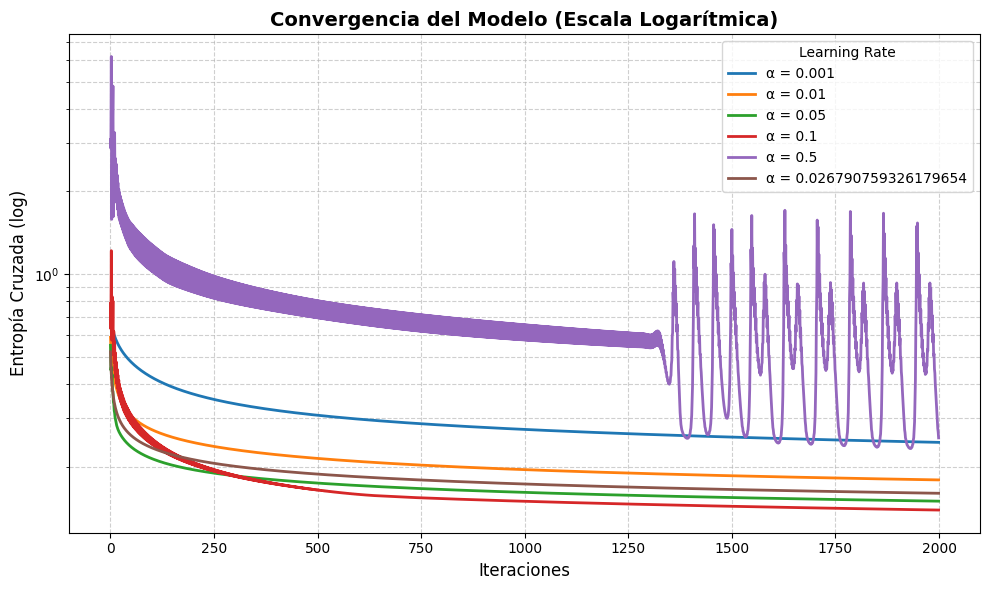

In [19]:
# --- Análisis de Convergencia: Optimización del Learning Rate ---

plt.figure(figsize=(10, 6))

for lr, historia in historias.items():
    # Graficamos directamente en escala logarítmica
    plt.semilogy(historia, label=f"α = {lr}", linewidth=2)

# Referencia a la cota teórica en el título o leyenda
plt.title("Convergencia del Modelo (Escala Logarítmica)", fontsize=14, fontweight='bold')
plt.xlabel("Iteraciones", fontsize=12)
plt.ylabel("Entropía Cruzada (log)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(title="Learning Rate", loc='best')

# Tip de Profe: Ajustar los márgenes para que se vea impecable
plt.tight_layout()
plt.show()

**Estudio del número de iteraciones**

Una vez identificada la tasa de aprendizaje adecuada, queda determinar cuántas iteraciones son necesarias. La idea es encontrar el punto a partir del cual la función de costo deja de disminuir de forma apreciable: seguir iterando a partir de ahí no mejora el modelo y solo añade costo computacional.

Para eso se entrena el modelo elegido durante un número largo de iteraciones y se mide la **reducción relativa** de la pérdida entre iteraciones consecutivas:

$$
\delta_t = \frac{J_{t-1} - J_t}{J_{t-1}}
$$

Cuando $\delta_t$ cae por debajo de un umbral (por ejemplo $10^{-5}$), se puede considerar que el algoritmo ha convergido. El número de iteraciones hasta ese punto es la cantidad mínima necesaria.

In [ ]:
# --- Estudio del número de iteraciones ---
# Se entrena durante muchas iteraciones para ver cuándo la curva se aplana.

alpha_elegido = 0.0005  # Candidato elegido del barrido anterior (ajustar según el gráfico)
n_iters_largo = 5000

m_largo = BinaryLogisticRegression(learning_rate=alpha_elegido, n_iters=n_iters_largo)
m_largo.fit(X_train, y_train)

loss = np.array(m_largo.loss_history)

# Reducción relativa entre iteraciones consecutivas
delta = (loss[:-1] - loss[1:]) / (loss[:-1] + 1e-15)

umbral = 1e-5
iter_convergencia = np.argmax(delta < umbral)
if iter_convergencia == 0 and delta[0] >= umbral:
    iter_convergencia = n_iters_largo  # Nunca convergió

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(loss)
axes[0].axvline(x=iter_convergencia, color='red', linestyle='--', label=f"Convergencia ≈ iter {iter_convergencia}")
axes[0].set_title(f"Curva de pérdida — α = {alpha_elegido}")
axes[0].set_xlabel("Iteraciones")
axes[0].set_ylabel("Entropía cruzada")
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(delta)
axes[1].axhline(y=umbral, color='red', linestyle='--', label=f"Umbral δ = {umbral}")
axes[1].axvline(x=iter_convergencia, color='orange', linestyle='--', label=f"iter ≈ {iter_convergencia}")
axes[1].set_title("Reducción relativa por iteración (log)")
axes[1].set_xlabel("Iteraciones")
axes[1].set_ylabel("δ = (J_t-1 - J_t) / J_t-1")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Iteración estimada de convergencia (δ < {umbral}): {iter_convergencia}")

**Selección de hiperparámetros**

A partir de los dos estudios anteriores es posible tomar una decisión fundamentada:

- El gráfico de **barrido de tasas de aprendizaje** muestra cuál es el mayor $\alpha$ que converge de forma monótona y sin oscilaciones. Las curvas correspondientes a tasas demasiado grandes divergen o muestran picos visibles; las de tasas pequeñas convergen, pero muy lentamente.
- El gráfico de **reducción relativa** muestra el número de iteraciones a partir del cual el modelo dejó de aprender de manera significativa. Pasado ese punto, agregar iteraciones no mejora el resultado.

Con base en estos criterios, se elige la tasa de aprendizaje como la mayor que todavía produce convergencia estable en el gráfico de curvas, y el número de iteraciones como el valor en el que $\delta_t$ cae por debajo del umbral de $10^{-5}$, redondeando con un margen para asegurar que la curva haya terminado de descender. Estos valores se usan en el entrenamiento definitivo a continuación.

Para analizar el comportamiento del entrenamiento, se registra el valor de la loss en cada iteración y luego se grafica su evolución. Esto permite observar si el algoritmo converge de manera estable y si la función de costo disminuye a medida que avanzan las iteraciones.

Finalmente, una vez entrenado el modelo, su desempeño se evalúa tanto sobre el conjunto de entrenamiento como sobre el conjunto de test. Para ello se calculan dos métricas: el accuracy, que indica la proporción de muestras correctamente clasificadas, y la entropía cruzada, que permite evaluar la calidad de las probabilidades predichas por el clasificador.

In [ ]:
# --- PUNTO B.6 y B.7: Entrenamiento y Gráficos ---

# Se recomienda ajustar estos hiperparámetros según la convergencia visual
modelo = BinaryLogisticRegression(learning_rate=0.005, n_iters=2000)
modelo.fit(X_train_std, y_train)

# Gráfico de convergencia [Punto B.6]
plt.figure(figsize=(10, 5))
plt.plot(modelo.loss_history)
plt.title("Evolución de la Entropía Cruzada (Entrenamiento)")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Reporte de métricas [Punto B.7]
print(f"Train STD Accuracy: {modelo.accuracy(X_train_std, y_train):.4f}")
print(f"Test STD Accuracy:  {modelo.accuracy(X_test_std, y_test):.4f}")
print(f"Train STD Cross-Entropy: {modelo.cross_entropy(X_train_std, y_train):.4f}")
print(f"Test STD Cross-Entropy:  {modelo.cross_entropy(X_test_std, y_test):.4f}")

## Ítem C

In [ ]:
En este último ítem del trabajo práctico se extiende el problema de clasificación al caso multiclase. En lugar de distinguir entre dos comandos, ahora se busca identificar cuatro palabras distintas: `up`, `down`, `left` y `right`. El enfoque sigue siendo el mismo que en el ítem (B): se aplica el preprocesamiento del ítem (A) para extraer las bandas de energía en dB, se arma la base de datos con los cuatro comandos, se divide en entrenamiento y testeo, y se entrena un clasificador. La diferencia clave está en el modelo: en lugar de una regresión logística binaria con función sigmoide, se implementa una **regresión logística categórica** basada en la función softmax, capaz de estimar simultáneamente la probabilidad de pertenencia a cada una de las cuatro clases.

### Puntos 1 y 2

De forma análoga al ítem (B), en esta etapa se construye el conjunto de datos para el problema multiclase. Se seleccionan únicamente los audios correspondientes a los comandos `up`, `down`, `left` y `right`, que se etiquetan con enteros del 0 al 3:

- `up` → 0
- `down` → 1
- `left` → 2
- `right` → 3

Para garantizar que todos los audios generen exactamente 50 ventanas temporales al aplicar la STFT, se mantiene la misma longitud objetivo de 13 056 muestras calculada en el ítem (B):

$$
L = 512 + 49 \cdot 256 = 13056
$$

Al igual que antes, los audios más largos se recortan al final y los más cortos se completan con ceros.

In [ ]:
# --- PUNTO C.1 y C.2: Carga y unificación de audios (multiclase) ---

target_samples = 13056
clases_c = ['up', 'down', 'left', 'right']
X_raw_c = []
y_labels_c = []

print("Iniciando carga de audios (multiclase)...")

for label_idx, clase in enumerate(clases_c):
    clase_path = os.path.join("speech_data", clase)
    archivos = [f for f in os.listdir(clase_path) if f.endswith('.wav')]

    for archivo in archivos:
        path = os.path.join(clase_path, archivo)
        y_audio, sr = librosa.load(path, sr=None)

        # Ajuste de longitud [Punto C.2]
        if len(y_audio) > target_samples:
            y_audio = y_audio[:target_samples]          # Recorte al final
        elif len(y_audio) < target_samples:
            y_audio = np.pad(y_audio, (0, target_samples - len(y_audio)), mode='constant')  # Zero-padding

        if len(y_audio) != target_samples:
            raise ValueError(f"Audio con longitud inesperada: {len(y_audio)}")

        X_raw_c.append(y_audio)
        y_labels_c.append(label_idx)  # up=0, down=1, left=2, right=3

X_raw_c = np.array(X_raw_c)
y_labels_c = np.array(y_labels_c)

print(f"Base de datos multiclase construida: {len(X_raw_c)} muestras en total.")
print(f"Distribución de clases: { {c: int(np.sum(y_labels_c == i)) for i, c in enumerate(clases_c)} }")

### Punto 3

Una vez unificada la duración de todos los audios, se aplica el mismo flujo de preprocesamiento definido en el ítem (A). Para cada audio, se calcula la STFT con las mismas configuraciones (FFT de 512 puntos, 50 % de solapamiento, ventana Hann), luego se agrupan los bins espectrales en 20 bandas de energía y, finalmente, esas energías se convierten a dB.

El resultado de procesar cada audio es una matriz de $20 \times 50$: 20 filas correspondientes a las bandas de frecuencia y 50 columnas correspondientes a las ventanas temporales. Dado que el clasificador requiere vectores como entrada, cada matriz se aplana en un único vector de:

$$
20 \cdot 50 = 1000
$$

características. Así, cada audio queda representado de la misma manera que en el ítem (B), y la diferencia entre ambos problemas está exclusivamente en la cantidad de clases, no en la representación de las señales.

In [ ]:
# --- PUNTO C.3: Preprocesamiento y aplanado (multiclase) ---

features_c = []

print("Extrayendo bandas de energía en dB (multiclase)...")

for audio in X_raw_c:
    # Se reutilizan las funciones del Ítem A
    espectro = calcular_stft_tp(audio)
    bandas = calcular_bandas_20(espectro)
    bandas_db = energia_a_db(bandas)

    # Chequeo de forma esperada
    if bandas_db.shape != (20, 50):
        raise ValueError(f"Forma inesperada: {bandas_db.shape}")

    # Aplanado de la muestra (1000 características por audio)
    features_c.append(bandas_db.flatten())

X_c = np.array(features_c)
y_c = y_labels_c

print(f"Matriz de características final: {X_c.shape} (Muestras, Features)")

### Punto 4

Al igual que en el caso binario, los datos se dividen de forma aleatoria en un conjunto de entrenamiento (80 %) y uno de testeo (20 %). El conjunto de entrenamiento se utiliza para ajustar los parámetros del modelo, mientras que el de testeo queda reservado para evaluar su capacidad de generalización sobre muestras no vistas.

Como paso adicional, las características se estandarizan usando la media y el desvío estándar calculados exclusivamente sobre el conjunto de entrenamiento. Esto garantiza que la información del conjunto de testeo no "contamine" al modelo durante el aprendizaje y que todas las variables de entrada queden en una escala comparable, favoreciendo la convergencia del descenso por gradiente.

In [ ]:
# --- PUNTO C.4: División entrenamiento y testeo (80/20) ---

indices_c = np.arange(len(X_c))
np.random.shuffle(indices_c)

split_c = int(0.8 * len(X_c))
train_idx_c, test_idx_c = indices_c[:split_c], indices_c[split_c:]

X_train_c, X_test_c = X_c[train_idx_c], X_c[test_idx_c]
y_train_c, y_test_c = y_c[train_idx_c], y_c[test_idx_c]

# Estandarización usando estadísticas del conjunto de entrenamiento
mu_c    = np.mean(X_train_c, axis=0)
sigma_c = np.std(X_train_c, axis=0) + 1e-10

X_train_c_std = (X_train_c - mu_c) / sigma_c
X_test_c_std  = (X_test_c  - mu_c) / sigma_c

print(f"Entrenamiento: {X_train_c.shape[0]} muestras. Testeo: {X_test_c.shape[0]} muestras.")
print("Estandarización aplicada usando estadísticas del conjunto de entrenamiento.")
print("Forma X_train_c_std:", X_train_c_std.shape)
print("Forma X_test_c_std:", X_test_c_std.shape)

### Punto 5

En este punto se implementa una regresión logística categórica para clasificar entre cuatro comandos de voz. Es una generalización directa del caso binario: en lugar de producir una única probabilidad para dos clases, el modelo produce un vector de probabilidades, una por clase.

**Del caso binario al multiclase**

En la regresión logística binaria, el modelo calcula un único puntaje lineal $z$ y lo comprime al intervalo $(0, 1)$ mediante la función sigmoide. En el caso multiclase con $K$ clases, se calcula un puntaje lineal independiente para cada clase:

$$
z_k = w_k^T x + b_k, \quad k = 1, 2, \dots, K
$$

donde $w_k \in \mathbb{R}^n$ es el vector de pesos asociado a la clase $k$, $b_k$ es su bias y $x \in \mathbb{R}^n$ es el vector de características. En este trabajo, $n = 1000$ y $K = 4$.

Todos estos puntajes se agrupan en un vector $z = [z_1, z_2, z_3, z_4]^T$ y se transforman mediante la función **softmax**:

$$
\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \quad k = 1, \dots, K
$$

La salida $\hat{y} = [\hat{y}_1, \hat{y}_2, \hat{y}_3, \hat{y}_4]^T$ puede interpretarse como un vector de probabilidades estimadas: cada componente indica qué tan compatible resulta la muestra con cada clase, y la suma de todas ellas es siempre igual a 1. La clase predicha es aquella con mayor probabilidad:

$$
\hat{c} = \arg\max_k \hat{y}_k
$$

Para que el cálculo de la exponencial no genere desbordamientos numéricos (*overflow*), se usa una versión estable de la softmax: antes de exponenciar, se resta el máximo del vector $z$ a cada componente. Esto no cambia el resultado matemático —ya que la constante se cancela en numerador y denominador— pero evita que aparezcan valores extremadamente grandes en los cálculos intermedios.

**Codificación en caliente (*one-hot encoding*)**

Para trabajar con las etiquetas durante el entrenamiento, cada etiqueta entera $y_i \in \{0, 1, 2, 3\}$ se convierte en un vector $K$-dimensional de ceros con un único 1 en la posición correspondiente a la clase. Por ejemplo, si $y_i = 2$ (clase `left`):

$$
y_i \xrightarrow{\text{one-hot}} [0, 0, 1, 0]
$$

Esta representación permite calcular directamente la diferencia entre las probabilidades predichas y las etiquetas reales, de manera matricial y eficiente.

**Función de costo: entropía cruzada categórica**

La función de costo se define como la entropía cruzada extendida al caso de $K$ clases. Para una muestra individual:

$$
\mathcal{L}(y, \hat{y}) = -\sum_{k=1}^{K} y_k \log(\hat{y}_k)
$$

Como la codificación one-hot tiene un solo 1, esta suma colapsa a $-\log(\hat{y}_{c})$, donde $c$ es la clase verdadera. Esto significa que la pérdida penaliza únicamente qué tan baja estima el modelo la probabilidad de la clase correcta.

Para un conjunto de $N$ muestras, la función de costo total es el promedio:

$$
J = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})
$$

**Gradiente descendente**

Los parámetros del modelo se organizan en una matriz de pesos $W \in \mathbb{R}^{n \times K}$ y un vector de bias $b \in \mathbb{R}^K$. Los gradientes de $J$ respecto a estos parámetros tienen una forma compacta y elegante. Definiendo $\hat{Y} \in \mathbb{R}^{N \times K}$ como la matriz de probabilidades predichas e $Y \in \mathbb{R}^{N \times K}$ como la matriz one-hot de etiquetas reales:

$$
\frac{\partial J}{\partial W} = \frac{1}{N} X^T \left(\hat{Y} - Y\right)
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} \left(\hat{y}_i - y_i\right)
$$

Estas expresiones son idénticas en forma a las del caso binario, lo que muestra que la regresión logística categórica es su generalización natural. En cada iteración, los parámetros se actualizan restando el gradiente escalado por la tasa de aprendizaje $\eta$:

$$
W \leftarrow W - \eta \cdot \frac{\partial J}{\partial W}, \qquad b \leftarrow b - \eta \cdot \frac{\partial J}{\partial b}
$$

In [ ]:
# --- PUNTO C.5: Clase CategoricalLogisticRegression ---

class CategoricalLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _softmax(self, z):
        # Versión numéricamente estable: se resta el máximo por fila
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y, n_classes):
        n = len(y)
        oh = np.zeros((n, n_classes))
        oh[np.arange(n), y] = 1
        return oh

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Inicialización de parámetros
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)
        self.loss_history = []

        Y_oh = self._one_hot(y, n_classes)

        for _ in range(self.n_iters):
            # Puntajes lineales + softmax
            z = np.dot(X, self.weights) + self.bias
            y_predicted = self._softmax(z)

            # Gradientes
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - Y_oh))
            db = (1 / n_samples) * np.sum(y_predicted - Y_oh, axis=0)

            # Actualización de parámetros
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Guardar la pérdida de la iteración actual
            self.loss_history.append(self.cross_entropy(X, y))

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._softmax(z)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    def cross_entropy(self, X, y):
        y_pred = self.predict_proba(X)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        n_classes = y_pred.shape[1]
        Y_oh = self._one_hot(y, n_classes)
        return -np.mean(np.sum(Y_oh * np.log(y_pred), axis=1))

### Puntos 6 y 7

Con el modelo implementado, se entrena la regresión logística categórica sobre el conjunto de entrenamiento estandarizado. Al igual que en el ítem (B), se registra el valor de la entropía cruzada en cada iteración y se grafica su evolución para verificar que el algoritmo converge de manera estable. Si la curva oscila o diverge, se ajustan los hiperparámetros (tasa de aprendizaje o cantidad de iteraciones) hasta obtener una convergencia visualmente clara.

Una vez entrenado, el desempeño del clasificador se evalúa sobre ambos conjuntos. Las métricas reportadas son:
- **Accuracy**: proporción de audios correctamente clasificados.
- **Entropía cruzada categórica**: calidad de las probabilidades predichas.

Se espera que el accuracy de testeo sea inferior al de entrenamiento, ya que el modelo fue ajustado únicamente sobre los datos de entrenamiento. Una brecha pequeña indica buena generalización; una brecha grande puede indicar sobreajuste. También es válido que ambos valores sean menores que en el caso binario: distinguir entre cuatro clases es, en principio, un problema más difícil que distinguir entre dos.

In [ ]:
# --- PUNTO C.6 y C.7: Entrenamiento y evaluación (multiclase) ---

modelo_c = CategoricalLogisticRegression(learning_rate=0.005, n_iters=2000)
modelo_c.fit(X_train_c_std, y_train_c)

# Gráfico de convergencia [Punto C.6]
plt.figure(figsize=(10, 5))
plt.plot(modelo_c.loss_history)
plt.title("Evolución de la Entropía Cruzada Categórica (Entrenamiento)")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Reporte de métricas [Punto C.7]
print(f"Train Accuracy: {modelo_c.accuracy(X_train_c_std, y_train_c):.4f}")
print(f"Test  Accuracy: {modelo_c.accuracy(X_test_c_std,  y_test_c):.4f}")
print(f"Train Cross-Entropy: {modelo_c.cross_entropy(X_train_c_std, y_train_c):.4f}")
print(f"Test  Cross-Entropy: {modelo_c.cross_entropy(X_test_c_std,  y_test_c):.4f}")